Cambios: 
- Implementacion noiseless simple
- Simulación via qiskit_aer (en GPUs)
- Optimicación pytorch para multiples GPUs
- Amplitude embedding


## Introduction

The Quantum Generative Adversarial Network (QGAN) [[1]](https://github.com/Qiskit/textbook/blob/main/notebooks/quantum-machine-learning/qgan.ipynb)  [[2]](https://arxiv.org/abs/1406.2661) we propose consists of two Quantum Neural Network (QNN) [[3]](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html): a generator and a discriminator. The generator is responsible for creating synthetic data samples. The discriminator evaluates the authenticity of the created samples by distinguishing between real and generated data. Through an adversarial training process, both networks continuously improve, leading to the generation of increasingly realistic data. 
This fully quantum approach benefits from the strengths of quantum state preparation and gradient calculation combined with classical optimizators [[4]](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
The data used to train the QGAN in this implementation is a probability distributions.

This implementation uses aer_simulator_statevector.

## Implementation (statevector simulation)

In [1]:
#--- INSTALATION INSTRUCTIONS ---#

# For linux 64-bit systems,
#uname -a

# Conda quick installation
#mkdir -p ~/miniconda3
#wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
#bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
#rm ~/miniconda3/miniconda.sh

# Create enviroment with conda
#conda create -n myenv python=3.10
#conda activate myenv
#pip install qiskit qiskit-machine-learning 'qiskit-machine-learning[sparse]' qiskit_aer qiskit_algorithms torch matplotlib pylatexenc ipykernelc
# IMPORTANT: Make sure you are on 3.10
# May need to restart the kernel after instalation

#--- Imports ---#
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import random_statevector, Statevector, SparsePauliOp
from qiskit.circuit.library import real_amplitudes, efficient_su2
from qiskit.utils import parallel_map
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as EstimatorV2_sim
from qiskit_aer.quantum_info import AerStatevector

from qiskit_algorithms.gradients import ReverseEstimatorGradient

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import os
import signal
import datetime as dt

In [2]:
#- Configuration -#

# Training configuration dict
train_config = {
    'execution_type': "noiseless_simulation", #noiseless_simulation
    'n_qubits': 3,
    'seed': 2,
    'id': None, # For different circuits or training parameters
    'reset_data': True,

    'create_circuits': True, # Create circuits manually or load from file
    'gradient_method': "REG", # qiskit_algorithms.gradients For now: PSR, SPSA and REG
    'max_iterations': 1000,
    'gen_iterations': 1,
    'disc_iterations': 3,
    'batch_size': 4, # How many samples' gradients are going to be calculated in a step
    'real_rate': 0.5, # Rate of training discriminator with real samples instead of generated samples
    'random_input': False, # Add randomness in the input when generating a sample
    'save_loss_iterations': 10, # Calculate extra forward pass to save loss
    'print_progress_iterations': 10,

    'training_data_file': None, # Automatically created with manage_files function
    'circuits_file': None, # Automatically created with manage_files function
    'backend_file': None, # Automatically created with manage_files function
    'dataset_file': None # Automatically created with manage_files function
}


# File management
def manage_files(
        data_folder_name = 'data', 
        implementation_name = 'noiseless_torch_opt_amp', 
        execution_type_name = train_config['execution_type'], 
        training_data_file_name = 'training_data', 
        circuits_file_name = 'circuits', 
        backend_file_name = 'backend',
        dataset_file_name = 'dataset'
        ):
    
    data_folder = data_folder_name + '/' + implementation_name + '/' + execution_type_name + '/' + 'q' + str(train_config['n_qubits']) + '/' + 'seed' + str(train_config['seed']) + '/'
    if train_config['id'] is not None:
        data_folder = data_folder + '/' + str(train_config['id']) + '/' 
    training_data_file = data_folder + training_data_file_name + '.pth'
    circuits_file = data_folder + circuits_file_name + '.qpy'
    backend_file = data_folder + backend_file_name + '.pkl'
    dataset_file = data_folder + dataset_file_name + '.npy'

    # Create folders if they do not exist
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)

    return training_data_file, circuits_file, backend_file, dataset_file



if ((train_config['training_data_file'] is None) and (train_config['circuits_file'] is None) and (train_config['backend_file'] is None)):
    train_config['training_data_file'], train_config['circuits_file'], train_config['backend_file'], train_config['dataset_file'] = manage_files()

In [3]:
#- Backend configuration -#
backend_config = {
    # Real backend
    'name': "ibm_basquecountry",
    'channel': "ibm_quantum_platform",

    # Noisy backend
    'reset_backend': False, # Get current backend state or load from file
    'timestamp': dt.datetime.now(), # dt.datetime(year=2026, month=12, day=5, hour = 10, tzinfo=dt.timezone.utc), # Get exact backend state, None to get current state (no he conseguido q funcione) TODO?

    # Noiseless backend
    'sim_options': {
        'method': 'statevector', # automatic, stabilizer (for clifford (simple) gates), matrix_product_state (low entanglement, more qubits), density_matrix (noise simulation, more memory (2^{2n} vs 2^n))
        #'device': 'GPU', # Para nvidia cuda
        'precision': 'single',       # Significant speedup 
        #'cuStateVec_enable': True,   # NVIDIA library optimization
        #'batched_shots_gpu': True,   # Parallelize batch on GPU [9]
        #'blocking_enable': False,     # Disable chunking; simulation fits in VRAM 
        #'target_gpus':[0,1],
        #'seed_simulator': train_config['seed']
    }
}

backend = AerSimulator(**backend_config['sim_options'])

precision = 0.0
estimator = EstimatorV2_sim(
    options = {
        "default_precision": precision,
        #'seed_estimator': train_config['seed'],
        "backend_options": backend_config['sim_options'],
        "run_options": {}
    })

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
#pm = None


# Select device torch
if torch.cuda.is_available():
    print(f"GPUs available to PyTorch: {torch.cuda.device_count()}")
    os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

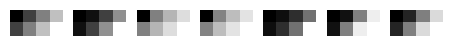

dataset shape: (7, 2, 4) 
data type: float64


In [4]:
#- Load dataset -#

# Build my own dataset of images: gradient images
def apply_curve(x, curve):
    if curve == 'linear':
        return x
    elif curve == 'quadratic':
        return x ** 2
    elif curve == 'sqrt':
        return np.sqrt(x)
    elif curve == 'log':
        return np.log1p(x * 9) / np.log(10)  # scale [0,1] into [0,1] log space
    elif curve == 'exp':
        return (np.exp(x * 3) - 1) / (np.exp(3) - 1)  # normalized exponential
    elif curve == 'sigmoid':
        return 1 / (1 + np.exp(-10 * (x - 0.5)))  # smooth S-curve
    elif curve == 'sin':
        return 0.5 * (1 - np.cos(np.pi * x))  # smooth start and end
    else:
        raise ValueError(f"Unknown curve type: {curve}")

def create_gradients(total_pixels, directions=None, curves=None, width=None, height=None):
    if directions is None:
        directions = [
            'top_left_to_bottom_right'
        ]
    if curves is None:
        curves = ['linear', 'quadratic', 'sqrt', 'log', 'exp', 'sigmoid', 'sin']

    if width is None or height is None:
        for h in range(int(np.sqrt(total_pixels)), 0, -1):
            if total_pixels % h == 0:
                width, height = total_pixels // h, h
                break
    elif width * height != total_pixels:
        raise ValueError("Provided width and height do not match total number of pixels.")

    max_val = 255
    gradients = []

    i, j = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Precompute normalized coordinate matrices for all directions
    norm_maps = {
        'left_to_right': np.tile(np.linspace(0, 1, width), (height, 1)),
        'right_to_left': np.tile(np.linspace(1, 0, width), (height, 1)),
        'top_to_bottom': np.tile(np.linspace(0, 1, height)[:, np.newaxis], (1, width)),
        'bottom_to_top': np.tile(np.linspace(1, 0, height)[:, np.newaxis], (1, width)),
        'top_left_to_bottom_right': (i + j) / (width + height - 2),
        'bottom_right_to_top_left': ((height - 1 - i) + (width - 1 - j)) / (width + height - 2),
        'top_right_to_bottom_left': (i + (width - 1 - j)) / (width + height - 2),
        'bottom_left_to_top_right': ((height - 1 - i) + j) / (width + height - 2)
    }

    for direction in directions:
        if direction not in norm_maps:
            raise ValueError(f"Unknown direction: {direction}")
        base_map = norm_maps[direction]

        for curve in curves:
            # Apply curve to normalized map
            curved_map = apply_curve(base_map, curve)
            gradients.append(curved_map)

    # Save in file
    image_array = np.array(gradients).reshape(-1, height, width)
    np.save(train_config['dataset_file'], image_array)


# Load circuits from file
try:
    X = np.load(train_config['dataset_file'])
except FileNotFoundError:
    print("Dataset file not found. Creating new dataset file.")
    create_gradients(2**train_config['n_qubits'])
    X = np.load(train_config['dataset_file'])


# Show dataset
for i in range(len(X)):
    plt.subplot(1,len(X)+1,i+1)
    plt.imshow(X[i], cmap="gray")
    plt.axis("off")
plt.show()
print("dataset shape:", X.shape, "\ndata type:", X.dtype)

In [5]:
#- Amplitude embedding -#

# Create real data sample circuit
def generate_real_circuit(matrices = None):
    n_qubits = train_config['n_qubits']

    if (matrices is None) or (matrices is []):
        ''' 
        # Random statevector
        sv = random_statevector(2**n_qubits, seed=train_config['seed'])
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(sv, qc.qubits, normalize=True) 
        '''

        # Specific statevector
        qc = QuantumCircuit(n_qubits)
        qc.h(range(n_qubits-1))
        qc.cx(n_qubits-2, n_qubits-1)
        return [qc]
    
    else:
        # Amplitude embedding
        qcs = []
        for matrix in matrices:
            qc = QuantumCircuit(n_qubits)
            qc.prepare_state(state=matrix.flatten(),
                            qubits=qc.qubits,
                            normalize=True)
            qcs.append(qc)
        return qcs

In [6]:
#- Create quantum circuits -#

# Create real data sample circuit
def generate_real_circuit():
    n_qubits = train_config['n_qubits']

    # sv = random_statevector(2**N_QUBITS, seed=SEED)
    # qc = QuantumCircuit(N_QUBITS)
    # qc.prepare_state(sv, qc.qubits, normalize=True)

    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits-1))
    qc.cx(n_qubits-2, n_qubits-1)
    return qc


# Create generator
def generate_generator():
    n_qubits = train_config['n_qubits']

    qc = real_amplitudes(n_qubits,
                        reps=3, # Number of layers
                        parameter_prefix='θ_g',
                        name='Generator')
    
    return qc.decompose()


# Create discriminator
def generate_discriminator():
    n_qubits = train_config['n_qubits']

    qc = efficient_su2(n_qubits,
                      entanglement="reverse_linear",
                      reps=1, # Number of layers
                      parameter_prefix='θ_d',
                      name='Discriminator').decompose()


    param_index = qc.num_parameters

    for i in reversed(range(n_qubits - 1)):
        qc.cx(i, n_qubits - 1)

    #qc.rx(disc_weights[param_index], N_QUBITS-1); param_index += 1
    qc.ry(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    qc.rz(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    
    return qc


# Create quantum circuits
def create_circuits():
    real_circuit = generate_real_circuit()
    generator_circuit = generate_generator()
    discriminator_circuit = generate_discriminator()

    # Save circuits in a file
    with open(train_config['circuits_file'], 'wb') as fd:
        qpy.dump([real_circuit, generator_circuit, discriminator_circuit], fd)


# Rewrite circuits file if indicated in options
if train_config['create_circuits']:
    create_circuits()


# Load circuits from file
try:
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
except FileNotFoundError:
    print("Circuits file not found. Creating new circuits file.")
    create_circuits()
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
    
    
real_circuit = circuits[0]
generator_circuit = circuits[1]
discriminator_circuit = circuits[2]

In [ ]:
#- Set up training quantum circuits -#
def generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit):
    n_qubits = train_config['n_qubits']

    # Connect real data and discriminator
    real_disc_circuit = QuantumCircuit(n_qubits)
    real_disc_circuit.compose(real_circuit, inplace=True)
    real_disc_circuit.compose(discriminator_circuit, inplace=True)

    # Connect generator and discriminator
    gen_disc_circuit = QuantumCircuit(n_qubits)
    gen_disc_circuit.compose(generator_circuit, inplace=True)
    gen_disc_circuit.compose(discriminator_circuit, inplace=True)

    # Connect real cirucit to generator and discriminator to use it for random input
    if train_config['random_input']:
        base_gen_disc_circuit = gen_disc_circuit
        gen_disc_circuit = QuantumCircuit(n_qubits)
        gen_disc_circuit.compose(real_circuit, inplace=True)
        gen_disc_circuit.compose(base_gen_disc_circuit, inplace=True)


    # Gradient computation method
    if train_config['gradient_method'] == 'SPSA':
        gradient = SPSAEstimatorGradient(estimator=estimator)
    elif train_config['gradient_method'] == 'REG':
        gradient = ReverseEstimatorGradient()
    else:
        gradient = ParamShiftEstimatorGradient(estimator=estimator)


    # Observables
    H1 = SparsePauliOp.from_list([("Z" + "I"*(n_qubits-1), 1.0)])


    N_DPARAMS = discriminator_circuit.num_parameters

    # specify QNN to update generator parameters
    gen_qnn = EstimatorQNN(circuit=gen_disc_circuit,
                        input_params=gen_disc_circuit.parameters[:N_DPARAMS], # fixed parameters (discriminator parameters)
                        weight_params=gen_disc_circuit.parameters[N_DPARAMS:], # parameters to update (generator parameters)
                        estimator=estimator,
                        observables=[H1],
                        gradient=gradient,
                        default_precision=precision,
                        pass_manager=pm
                        )

    # specify QNN to update discriminator parameters regarding to fake data
    disc_fake_qnn = EstimatorQNN(circuit=gen_disc_circuit, 
                            input_params=gen_disc_circuit.parameters[N_DPARAMS:], # fixed parameters (generator parameters) TODO cambia parametros input/weight para añadir random, sube la opcion para cuando se creen los estimatorQNN y (cambia como saveas los circuitos) dependiendo como sea el circuito loadeado hacer uno o otro. A no, generalizalo sinmas y ya esta, input params = [] para no randomness
                            weight_params=gen_disc_circuit.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=[H1],
                            gradient=gradient,
                            default_precision=precision,
                            pass_manager=pm
                            )

    # specify QNN to update discriminator parameters regarding to real data
    disc_real_qnn = EstimatorQNN(circuit=real_disc_circuit,
                            input_params=real_disc_circuit.parameters[N_DPARAMS:], # fixed parameters (real data parameters)
                            weight_params=real_disc_circuit.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=[H1],
                            gradient=gradient,
                            default_precision=precision,
                            pass_manager=pm
                            )
    

    return gen_qnn, disc_fake_qnn, disc_real_qnn

gen_qnn, disc_fake_qnn, disc_real_qnn = generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit)

In [ ]:
#- Restore parameters and model states -#

# Reset all data training
def reset_data(n_gen_params, n_disc_params):
    np.random.seed(train_config['seed'])

    init_gen_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_gen_params,)) * 0.1 # Start from near 0 parameters to mitigate drastic changes at the start
    init_disc_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_disc_params,)) * 0.1

    gen_params = torch.tensor(init_gen_params, requires_grad=True, dtype = torch.float32)
    disc_params = torch.tensor(init_disc_params, requires_grad=True, dtype = torch.float32)

    optimizer_g = torch.optim.Adam([gen_params], lr=0.005)
    optimizer_d = torch.optim.Adam([disc_params], lr=0.005)

    torch.save({
        'init_gen_params': init_gen_params,
        'init_disc_params': init_disc_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'best_gen_params': init_gen_params,
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
        'current_epoch': 0,
        "metrics": {
            "gloss": {},
            "dloss": {},
            "kl_div": {},
            'times': {},
        },
        'random_state': np.random.get_state()
    }, train_config['training_data_file'])


# Load parameters and training states
if train_config['reset_data']:
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)

try:
    params = torch.load(train_config['training_data_file'], weights_only=False)
except FileNotFoundError:
    print("Training data file not found. Resetting parameters.")
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)
    params = torch.load(train_config['training_data_file'], weights_only=False)

np.random.set_state(params['random_state'])

gen_params = params['gen_params']
disc_params = params['disc_params']

optimizer_g = torch.optim.Adam([gen_params])
optimizer_d = torch.optim.Adam([disc_params])

optimizer_g.load_state_dict(params['optimizer_g_state'])
optimizer_d.load_state_dict(params['optimizer_d_state'])

current_epoch = params['current_epoch']
gloss = params['metrics']['gloss']
gen_loss = list(gloss)[-1] if (gloss) else None
dloss = params['metrics']['dloss']
disc_loss = list(dloss)[-1] if (dloss) else None
kl_div = params['metrics']['kl_div']
min_kl_div = np.min(list(kl_div.values())) if (kl_div) else float('inf')
best_gen_params = params['best_gen_params']
times = params['metrics']['times']

In [9]:
#- Manage training interruption -#

# Class to manage training interruption
class Interrupter:
    def __init__(self):
        self.kill_now = False
        self.interrupt_count = 0

        # Intercept the Ctrl+C signal
        signal.signal(signal.SIGINT, self.handle_signal)
        # Intercept the termination signal (useful for Docker/systems)
        #signal.signal(signal.SIGTERM, self.handle_signal)

    def handle_signal(self, signum, frame):
        self.interrupt_count += 1
        
        if self.interrupt_count == 1:
            # First Press: Enable graceful exit
            self.kill_now = True
            print("\nInterrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)")
        
        elif self.interrupt_count >= 2:
            # Second Press: Force quit immediately
            print("\nInterrupter: [!] Force quit triggered! Terminating immediately.")
            # Restore default signal handler to avoid recursion
            signal.signal(signal.SIGINT, signal.SIG_DFL)
            # Raise the exception to stop execution right here
            raise KeyboardInterrupt

In [ ]:
#- Evualuation method -#

# Evaluation method: KL-Div of generated (ger_dists) and real (targets) samples TODO Is it the best way for gradient images? (spoiler: NO)
def evaluate(gen_dists, targets):
    return torch.nn.functional.kl_div(
        input = gen_dists.log(),
        target = targets, 
        reduction = 'batchmean' 
    ).item()

In [ ]:
#- Batch parallelization -#

# Generate random input
def generate_random_input():
    # Replace 'num_input_params' with the actual number of 
    # random inputs your circuit requires.
    num_input_params = ran_gen_transpiled.num_parameters - len(gen_params_np)
    
    # Typically, parameters are sampled from [0, 2*pi] for rotation gates
    return np.random.uniform(0, 2 * np.pi, size=num_input_params)

# Compute forward pass in parallel
def compute_single_forward_gen(data_index):
    ran_input = 0 if train_config['random_input'] else []
    cost = gen_qnn.forward(ran_input + disc_params_np, gen_params_np)[0,0]
    return cost

def compute_single_forward_disc(data_index):
    if data_index == -1:
        ran_input = 0 if train_config['random_input'] else []
        cost = -disc_fake_qnn.forward(ran_input + gen_params_np, disc_params_np)[0,0]
    else:
        cost = disc_real_qnn.backward(real_params_np, disc_params_np)[1][0,0]

    return cost

# Compute gradients in parallel
def compute_single_gradient_gen(data_index):
    ran_input = 0 if train_config['random_input'] else []
    grad = gen_qnn.backward(ran_input + disc_params_np, gen_params_np)[1][0,0]
    return grad

def compute_single_gradient_disc(data_index):
    if data_index == -1:
        ran_input = 0 if train_config['random_input'] else []
        grad = -disc_fake_qnn.backward(ran_input + gen_params_np, disc_params_np)[1][0,0]
    else:
        grad = disc_real_qnn.backward(real_params, disc_params_np)[1][0,0]

    return grad


# Evaluate batch of generated samples with real samples # TODO noisy/real evaluation
def batch_evaluation(gen_params_np, targets):
    if train_config['random_input']:
        # Generate multiple samples from random inputs
        svs = []
        for i in range(len(targets)):
            ran_input = generate_random_input()
            sv = torch.from_numpy(AerStatevector(ran_gen_transpiled.assign_parameters(ran_input + gen_params_np)).probabilities())
            svs.append(sv)
        gen_dists = torch.stack(svs).to(device)
    else:
        # Use only the base case (all 0)
        gen_dists = torch.from_numpy(AerStatevector(gen_transpiled.assign_parameters(gen_params_np).probabilities()), device=device).expand(targets.size(0), -1)

    # Evalua con los real samples
    current_kl = evaluate(gen_dists, targets)

    return current_kl


# Create random input generator to evaluate in training
gen_transpiled = pm.run(generator_circuit)
ran_gen_transpiled = pm.run(generate_random_input_gen())

In [ ]:
#- Training -#

D_STEPS = train_config['disc_iterations']
G_STEPS = train_config['gen_iterations']
C_STEPS = train_config['save_loss_iterations']

# Compute real distributions
real_distribution_tensors = []
for real_circuit in real_circuits:
    real_distribution_tensor = torch.from_numpy(AerStatevector(real_circuit).probabilities()) # Retrieve real data probability distribution 
    real_distribution_tensors.append(real_distribution_tensor)
targets = torch.stack(real_distribution_tensors).to(device)

interrupter = Interrupter()

if train_config['print_progress_iterations']:
    TABLE_HEADERS = "Epoch | Generator cost | Discriminator cost | KL Div. | Best KL Div. | Time |"
    print(TABLE_HEADERS)

prev_times = 0
start_time = time.time()

#--- Training loop ---#
try: # In case of interruption
    for epoch in range(current_epoch, train_config['max_iterations']+1):

        #--- Quantum discriminator parameter updates ---#
        for disc_train_step in range(D_STEPS):
            real_params = [X[np.random.randint(0, len(X))].flatten() for i in range(train_config['batch_size'])][0]
            gen_params_np = gen_params.detach().cpu().numpy()
            disc_params_np = disc_params.detach().cpu().numpy()

            # Calculate discriminator cost (optional)
            if (disc_train_step == D_STEPS - 1) and (epoch % C_STEPS == 0):
                all_costs = parallel_map(compute_single_forward_disc, data_indexes)
                disc_loss = np.sum(all_costs, axis=0) / (len(all_costs) * 2) - 0.5 # to [-1,0]
                dloss[epoch] = disc_loss

            # Caltulate discriminator gradient
            all_grads = parallel_map(compute_single_gradient_disc, data_indexes)
            grad_dcost_adjoint = np.mean(all_grads, axis=0)
            
            # Update discriminator parameters
            optimizer_d.zero_grad()
            disc_params.grad = torch.tensor(grad_dcost_adjoint, dtype = torch.float32, device=device)
            optimizer_d.step()


        #--- Quantum generator parameter updates ---#
        for gen_train_step in range(G_STEPS):
            gen_params_np = gen_params.detach().cpu().numpy()
            disc_params_np = disc_params.detach().cpu().numpy()

            # Calculate generator cost
            if (disc_train_step == G_STEPS - 1) and (epoch % C_STEPS == 0):
                all_costs = parallel_map(compute_single_forward_gen, data_indexes)
                gen_loss = np.sum(all_costs, axis=0) / (len(all_costs) * 2) - 0.5 # to [-1,0]
                gloss[epoch] = gen_loss

            # Calculate generator gradient
            all_grads = parallel_map(compute_single_gradient_gen, data_indexes)
            grad_gcost_adjoint = np.mean(all_grads, axis=0)

            # Update generator parameters
            optimizer_g.zero_grad()
            gen_params.grad = torch.tensor(grad_gcost_adjoint, dtype = torch.float32, device=device)
            optimizer_g.step()


        #--- Track KL and save best performing generator weights ---#
        sv = AerStatevector(generator_circuit.assign_parameters(gen_params_np), device=device)
        gen_dist = torch.tensor(sv.probabilities(), device=device)

        # Performance measurement function: uses Kullback Leibler Divergence to measures the distance between two distributions TODO Is it the best way for gradient images? (spoiler: NO)
        real_data_indexes = [np.random.randint(0, len(real_distribution_tensors)) for i in range(train_config['batch_size'])]  
        current_kl = batch_evaluation(real_data_indexes)
        
        kl_div[epoch] = current_kl
        if min_kl_div > current_kl:
            min_kl_div = current_kl
            best_gen_params = gen_params_np.copy() # New best

        # Calculate time
        cur_time = (time.time() - start_time)
        times[epoch] = cur_time
        start_time = time.time()

        #--- Print progress ---#
        if train_config['print_progress_iterations'] and (epoch % train_config['print_progress_iterations'] == 0):
            now_times = sum(times.values())
            for header, val in zip(TABLE_HEADERS.split('|'),
                                (epoch, gen_loss, disc_loss, current_kl, min_kl_div, now_times - prev_times)):
                print(f"{val:.3g} ".rjust(len(header)), end="|")
            print()

            prev_times = now_times

        # In case of interruption
        if interrupter.kill_now:
            print("Interrupter: Graceful exit triggered. Breaking loop.")
            break
            
#--- Save parameters and optimizer states data ---#
finally:
    torch.save({
        'init_gen_params': params['init_gen_params'],
        'init_disc_params': params['init_disc_params'],
        'best_gen_params': best_gen_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
        'current_epoch': epoch+1,
        "metrics": {
            "gloss": gloss,
            "dloss": dloss,
            "kl_div": kl_div,
            'times': times,
        },
        'random_state': np.random.get_state()
    }, train_config['training_data_file'])
    
    kl_div_data = list(kl_div.values()) if kl_div else [0]
    print("Training complete:", "\n   Data path:", train_config['training_data_file'], "\n   Best KLDiv:", np.min(kl_div_data), "in epoch", np.argmin(kl_div_data), "\n   Improvement:", kl_div_data[0]-np.min(kl_div_data), "\n   Total time:", sum(times.values()))

Epoch | Generator cost | Discriminator cost | KL Div. | Best KL Div. | Time |


    0 |          -0.48 |             -0.567 |    2.56 |         2.56 |0.925 |
   10 |         -0.377 |             -0.647 |    2.66 |         2.56 | 6.94 |
   20 |         -0.334 |             -0.664 |    2.24 |         2.24 | 6.91 |
   30 |         -0.333 |             -0.779 |    2.34 |         2.22 | 6.44 |
   40 |         -0.335 |             -0.742 |    3.63 |         2.22 | 6.51 |
   50 |         -0.343 |              -0.78 |    2.47 |         2.22 | 6.42 |
   60 |         -0.337 |             -0.889 |    2.68 |         2.22 | 6.68 |
   70 |         -0.333 |             -0.789 |    2.79 |         2.22 | 6.38 |
   80 |         -0.328 |             -0.752 |    2.68 |         2.22 | 6.91 |
   90 |         -0.315 |              -0.68 |    6.38 |         2.22 | 6.67 |
  100 |         -0.336 |             -0.661 |    2.17 |         2.17 | 6.93 |
  110 |         -0.359 |             -0.774 |    1.53 |         1.53 | 6.24 |
  120 |         -0.381 |             -0.678 |    1.16 |         